In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import patches
import seaborn as sns

In [2]:
ccolors = plt.get_cmap('tab10')

# dispersal rates

In [3]:
def true_inf_disp_plot(d, tCutoff, SIGMAdisps, nreps, true_string, inferred_string, K, SIGMAmate, xmax=None, filename=None):

    # expected = [SIGMAdisp**2 for SIGMAdisp in SIGMAdisps] #ignores fact that higher variance to father
    expected = [(SIGMAdisp**2 + SIGMAmate**2/2) for SIGMAdisp in SIGMAdisps] #see Smith et al, https://academic.oup.com/genetics/article/224/2/iyad068/7117621
    expected = [(SIGMAdisp**2 + SIGMAmate**2/2)**0.5 for SIGMAdisp in SIGMAdisps] #see Smith et al, https://academic.oup.com/genetics/article/224/2/iyad068/7117621
    
    fig, axs = plt.subplots(1, 1, figsize=(5,5))

    mless = []
    for SIGMAdisp in SIGMAdisps:
        mles = []
        for nrep in nreps:
            mle = np.load(true_string %(K, SIGMAmate, SIGMAdisp, nrep, d, tCutoff))
            mles.append(mle)
        mless.append(mles)
    true_mless = np.array(mless)

    mless = []
    for SIGMAdisp in SIGMAdisps:
        mles = []
        for nrep in nreps:
            mle = np.load(inferred_string %(K, SIGMAmate, SIGMAdisp, nrep, d, tCutoff))
            mles.append(mle)
        mless.append(mles)
    inf_mless = np.array(mless)

    axs.plot([0,xmax], [0,xmax], c='k', zorder=0)
    for i,ex in enumerate(expected):
#         axs.scatter(true_mless[i,:,0]**2, inf_mless[i,:,0]**2, label='$\sigma^2=$%s, x' %ex, alpha=0.5, color=ccolors(i), marker='x')
#         axs.scatter(true_mless[i,:,1]**2, inf_mless[i,:,1]**2, label='$\sigma^2=$%s, y' %ex, alpha=0.5, color=ccolors(i), marker='o')
        axs.scatter(true_mless[i,:,0], inf_mless[i,:,0], label='$\sigma^2=$%s, x' %ex, alpha=0.75, color=ccolors(i), marker=r'$x$')
        axs.scatter(true_mless[i,:,1], inf_mless[i,:,1], label='$\sigma^2=$%s, y' %ex, alpha=0.75, color=ccolors(i), marker=r'$y$')
#         axs.scatter(ex, ex, marker='*')
        axs.plot([0,ex],[ex,ex], color=ccolors(i), alpha=0.75)
        axs.plot([ex,ex],[0,ex], color=ccolors(i), alpha=0.75)
    # axs.scatter(true_mless[:,:,0], inf_mless[:,:,0], label='x', alpha=0.5)
    # axs.scatter(true_mless[:,:,1], inf_mless[:,:,1], label='y', alpha=0.5)
    axs.set_xlabel(r'$\widehat{\sigma}$, true trees', fontsize=14)
    axs.set_ylabel(r'$\widehat{\sigma}$, inferred trees', fontsize=14)
    axs.set_ylim(0,xmax)
    axs.set_xlim(0,xmax)
#     plt.legend()
    if filename is not None:
        plt.savefig(filename)
    plt.show()

## no time cutoff

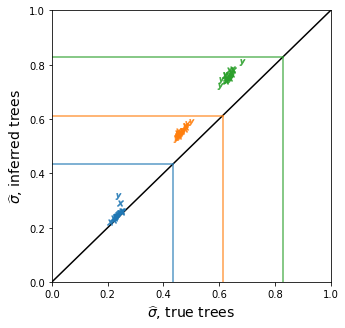

In [4]:
SIGMAmate = 0.5
K = 1.0
nreps = range(10)
tCutoff = 'None'
d = 100
SIGMAdisps = [0.25,0.5,0.75]

true_string = 'data/sim_100000000L_1e-08RBP_2.0LAMBDA_%sK_100W_1.0SIGMAcomp_%sSIGMAmate_%sSIGMAdisp_0selfing_40000MAXT_%dnrep_10000Ne_1e-08U_%dd_50k_2G_100treeskip_%stCutoff_mle-dispersal.npy'
inferred_string = 'data/sim_100000000L_1e-08RBP_2.0LAMBDA_%sK_100W_1.0SIGMAcomp_%sSIGMAmate_%sSIGMAdisp_0selfing_40000MAXT_%dnrep_10000Ne_1e-08U_%dd_50k_2G_5numiter_0.5threshold_100treeskip_1000M_%stCutoff_mle-dispersal.npy'

true_inf_disp_plot(d, tCutoff, SIGMAdisps, nreps, true_string, inferred_string, K, SIGMAmate, xmax=1, filename='plots/disp-Tnone.pdf')

## T=1000

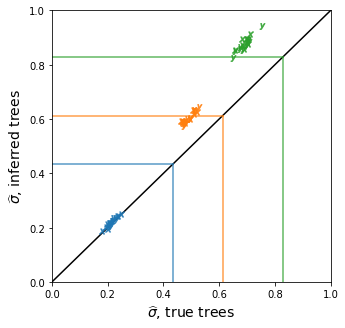

In [5]:
SIGMAmate = 0.5
K = 1.0
nreps = range(10)
tCutoff = 1000
d = 100
SIGMAdisps = [0.25,0.5,0.75]

true_string = 'data/sim_100000000L_1e-08RBP_2.0LAMBDA_%sK_100W_1.0SIGMAcomp_%sSIGMAmate_%sSIGMAdisp_0selfing_40000MAXT_%dnrep_10000Ne_1e-08U_%dd_50k_2G_100treeskip_%stCutoff_mle-dispersal.npy'
inferred_string = 'data/sim_100000000L_1e-08RBP_2.0LAMBDA_%sK_100W_1.0SIGMAcomp_%sSIGMAmate_%sSIGMAdisp_0selfing_40000MAXT_%dnrep_10000Ne_1e-08U_%dd_50k_2G_5numiter_0.5threshold_100treeskip_1000M_%stCutoff_mle-dispersal.npy'

true_inf_disp_plot(d, tCutoff, SIGMAdisps, nreps, true_string, inferred_string, K, SIGMAmate, xmax=1, filename='plots/disp-T1000.pdf')

## T=100

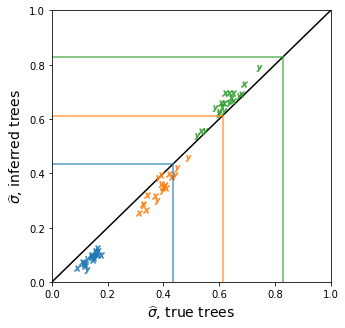

In [6]:
SIGMAmate = 0.5
K = 1.0
nreps = range(10)
tCutoff = 100
d = 100
SIGMAdisps = [0.25,0.5,0.75]

true_string = 'data/sim_100000000L_1e-08RBP_2.0LAMBDA_%sK_100W_1.0SIGMAcomp_%sSIGMAmate_%sSIGMAdisp_0selfing_40000MAXT_%dnrep_10000Ne_1e-08U_%dd_50k_2G_100treeskip_%stCutoff_mle-dispersal.npy'
inferred_string = 'data/sim_100000000L_1e-08RBP_2.0LAMBDA_%sK_100W_1.0SIGMAcomp_%sSIGMAmate_%sSIGMAdisp_0selfing_40000MAXT_%dnrep_10000Ne_1e-08U_%dd_50k_2G_5numiter_0.5threshold_100treeskip_1000M_%stCutoff_mle-dispersal.npy'

true_inf_disp_plot(d, tCutoff, SIGMAdisps, nreps, true_string, inferred_string, K, SIGMAmate, xmax=1, filename='plots/disp-T100.pdf')

## dispersal with fewer importance samples

In [3]:
def true_inf_disp_plot(d, tCutoff, SIGMAdisps, nreps, true_string, inferred_string, K, SIGMAmate, xmax=None, filename=None):

    # expected = [SIGMAdisp**2 for SIGMAdisp in SIGMAdisps] #ignores fact that higher variance to father
    expected = [(SIGMAdisp**2 + SIGMAmate**2/2) for SIGMAdisp in SIGMAdisps] #see Smith et al, https://academic.oup.com/genetics/article/224/2/iyad068/7117621
    expected = [(SIGMAdisp**2 + SIGMAmate**2/2)**0.5 for SIGMAdisp in SIGMAdisps] #see Smith et al, https://academic.oup.com/genetics/article/224/2/iyad068/7117621
    
    fig, axs = plt.subplots(1, 1, figsize=(5,5))

    mless = []
    for SIGMAdisp in SIGMAdisps:
        mles = []
        for nrep in nreps:
            mle = np.load(true_string %(K, SIGMAmate, SIGMAdisp, nrep, d, tCutoff))
            mles.append(mle)
        mless.append(mles)
    true_mless = np.array(mless)

    mless = []
    for SIGMAdisp in SIGMAdisps:
        mles = []
        for nrep in nreps:
            mle = np.load(inferred_string %(K, SIGMAmate, SIGMAdisp, nrep, d, tCutoff, m))
            mles.append(mle)
        mless.append(mles)
    inf_mless = np.array(mless)

    axs.plot([0,xmax], [0,xmax], c='k', zorder=0)
    for i,ex in enumerate(expected):
#         axs.scatter(true_mless[i,:,0]**2, inf_mless[i,:,0]**2, label='$\sigma^2=$%s, x' %ex, alpha=0.5, color=ccolors(i), marker='x')
#         axs.scatter(true_mless[i,:,1]**2, inf_mless[i,:,1]**2, label='$\sigma^2=$%s, y' %ex, alpha=0.5, color=ccolors(i), marker='o')
        axs.scatter(true_mless[i,:,0], inf_mless[i,:,0], label='$\sigma^2=$%s, x' %ex, alpha=0.75, color=ccolors(i), marker=r'$x$')
        axs.scatter(true_mless[i,:,1], inf_mless[i,:,1], label='$\sigma^2=$%s, y' %ex, alpha=0.75, color=ccolors(i), marker=r'$y$')
#         axs.scatter(ex, ex, marker='*')
        axs.plot([0,ex],[ex,ex], color=ccolors(i), alpha=0.75)
        axs.plot([ex,ex],[0,ex], color=ccolors(i), alpha=0.75)
    # axs.scatter(true_mless[:,:,0], inf_mless[:,:,0], label='x', alpha=0.5)
    # axs.scatter(true_mless[:,:,1], inf_mless[:,:,1], label='y', alpha=0.5)
    axs.set_xlabel(r'$\widehat{\sigma}$, true trees', fontsize=14)
    axs.set_ylabel(r'$\widehat{\sigma}$, inferred trees', fontsize=14)
    axs.set_ylim(0,xmax)
    axs.set_xlim(0,xmax)
#     plt.legend()
    if filename is not None:
        plt.savefig(filename)
    plt.show()

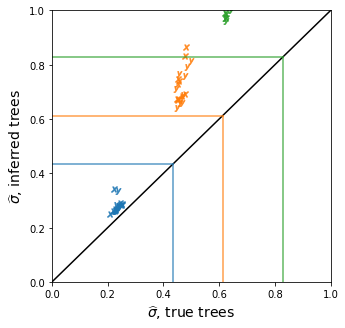

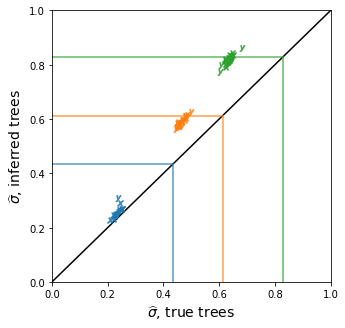

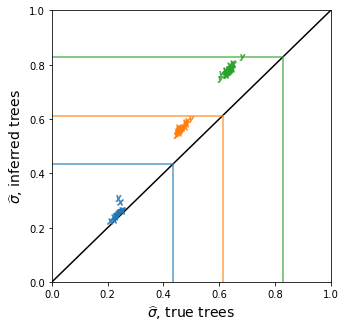

In [4]:
SIGMAmate = 0.5
K = 1.0
nreps = range(10)
tCutoff = 'None'
d = 100
SIGMAdisps = [0.25,0.5,0.75]

true_string = 'data/sim_100000000L_1e-08RBP_2.0LAMBDA_%sK_100W_1.0SIGMAcomp_%sSIGMAmate_%sSIGMAdisp_0selfing_40000MAXT_%dnrep_10000Ne_1e-08U_%dd_50k_2G_100treeskip_%stCutoff_mle-dispersal.npy'
inferred_string = 'data/sim_100000000L_1e-08RBP_2.0LAMBDA_%sK_100W_1.0SIGMAcomp_%sSIGMAmate_%sSIGMAdisp_0selfing_40000MAXT_%dnrep_10000Ne_1e-08U_%dd_50k_2G_5numiter_0.5threshold_100treeskip_1000M_%stCutoff_%dm_mle-dispersal.npy'

for m in [1,10,100]:
    filename = 'plots/disp-T%s-m%d.pdf' %(tCutoff,m)
    true_inf_disp_plot(d, tCutoff, SIGMAdisps, nreps, true_string, inferred_string, K, SIGMAmate, xmax=1, filename=filename)

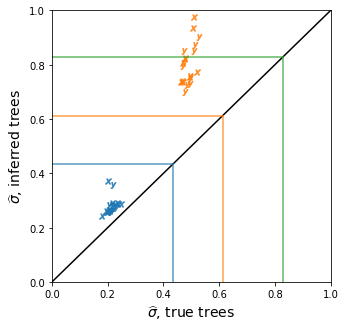

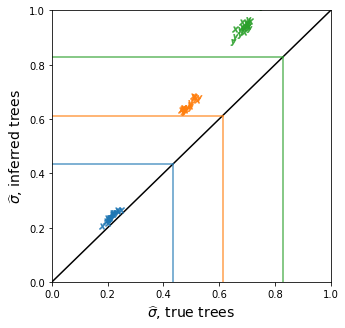

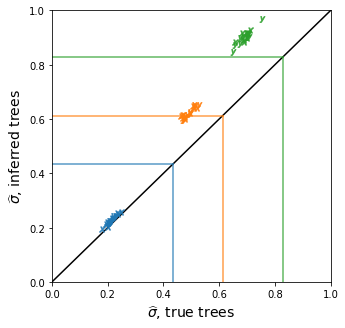

In [5]:
SIGMAmate = 0.5
K = 1.0
nreps = range(10)
tCutoff = 1000
d = 100
SIGMAdisps = [0.25,0.5,0.75]

true_string = 'data/sim_100000000L_1e-08RBP_2.0LAMBDA_%sK_100W_1.0SIGMAcomp_%sSIGMAmate_%sSIGMAdisp_0selfing_40000MAXT_%dnrep_10000Ne_1e-08U_%dd_50k_2G_100treeskip_%stCutoff_mle-dispersal.npy'
inferred_string = 'data/sim_100000000L_1e-08RBP_2.0LAMBDA_%sK_100W_1.0SIGMAcomp_%sSIGMAmate_%sSIGMAdisp_0selfing_40000MAXT_%dnrep_10000Ne_1e-08U_%dd_50k_2G_5numiter_0.5threshold_100treeskip_1000M_%stCutoff_%dm_mle-dispersal.npy'

for m in [1,10,100]:
    filename = 'plots/disp-T%d-m%d.pdf' %(tCutoff,m)
    true_inf_disp_plot(d, tCutoff, SIGMAdisps, nreps, true_string, inferred_string, K, SIGMAmate, xmax=1, filename=filename)

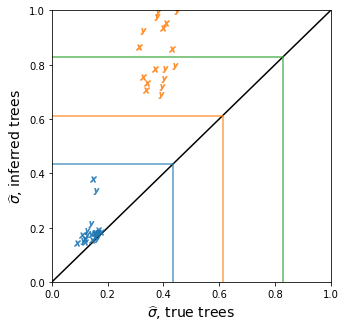

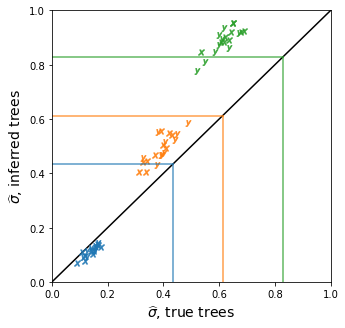

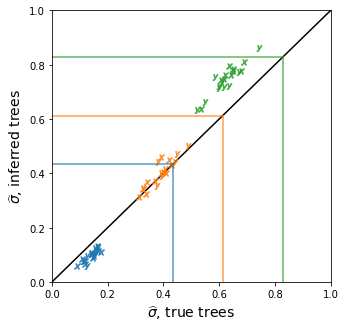

In [6]:
SIGMAmate = 0.5
K = 1.0
nreps = range(10)
tCutoff = 100
d = 100
SIGMAdisps = [0.25,0.5,0.75]

true_string = 'data/sim_100000000L_1e-08RBP_2.0LAMBDA_%sK_100W_1.0SIGMAcomp_%sSIGMAmate_%sSIGMAdisp_0selfing_40000MAXT_%dnrep_10000Ne_1e-08U_%dd_50k_2G_100treeskip_%stCutoff_mle-dispersal.npy'
inferred_string = 'data/sim_100000000L_1e-08RBP_2.0LAMBDA_%sK_100W_1.0SIGMAcomp_%sSIGMAmate_%sSIGMAdisp_0selfing_40000MAXT_%dnrep_10000Ne_1e-08U_%dd_50k_2G_5numiter_0.5threshold_100treeskip_1000M_%stCutoff_%dm_mle-dispersal.npy'

for m in [1,10,100]:
    filename = 'plots/disp-T%d-m%d.pdf' %(tCutoff,m)
    true_inf_disp_plot(d, tCutoff, SIGMAdisps, nreps, true_string, inferred_string, K, SIGMAmate, xmax=1, filename=filename)

# ancestor locations

In [4]:
SIGMAmate = 0.5
SIGMAdisp = 0.75
prefix = 'data/sim_100000000L_1e-08RBP_2.0LAMBDA_1.0K_100W_1.0SIGMAcomp_%sSIGMAmate_%sSIGMAdisp_0selfing_40000MAXT_0nrep_10000Ne_1e-08U_100d_50k_2G_100treeskip' %(SIGMAmate, SIGMAdisp)
filename = prefix + '_anc-locs.npy'
real_anc_locs = np.load(filename)
filename = prefix + '_NonetCutoff_ancestor-locations.npy'
true_anc_locs = np.load(filename)
filename = prefix + '_NonetCutoff_ancestor-variances.npy'
true_anc_vars = np.load(filename)

In [62]:
retain_gens = range(0,1001,100)
sigma2 = SIGMAdisp**2 + SIGMAmate**2/2
sigma = np.array([[sigma2,0],[0,sigma2]])

## single lineages

In [63]:
def _plot_cov_ellipse(cov, pos, nstd=2, ax=None, **kwargs):
    """
    Plots an `nstd` sigma error ellipse based on the specified covariance
    matrix (`cov`). Additional keyword arguments are passed on to the 
    ellipse patch artist.

    Parameters
    ----------
        cov : The 2x2 covariance matrix to base the ellipse on
        pos : The location of the center of the ellipse. Expects a 2-element
            sequence of [x0, y0].
        nstd : The radius of the ellipse in numbers of standard deviations.
            Defaults to 2 standard deviations.
        ax : The axis that the ellipse will be plotted on. Defaults to the 
            current axis.
        Additional keyword arguments are pass on to the ellipse patch.

    Returns
    -------
        A matplotlib ellipse artist
    """
    def _eigsorted(cov):
        vals, vecs = np.linalg.eigh(cov)
        order = vals.argsort()[::-1]
        return vals[order], vecs[:,order]

    if ax is None:
        ax = plt.gca()

    vals, vecs = _eigsorted(cov)
    theta = np.degrees(np.arctan2(*vecs[:,0][::-1]))

    # Width and height are "full" widths, not radius
    width, height = 2 * nstd * np.sqrt(vals)
    ellip = patches.Ellipse(xy=pos, width=width, height=height, angle=theta, **kwargs)

    ax.add_artist(ellip)
    return ellip

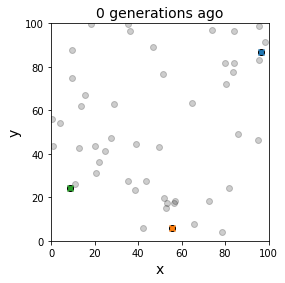

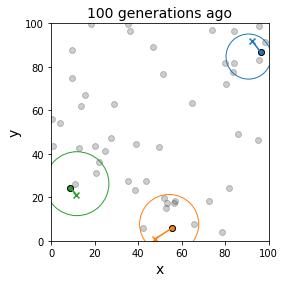

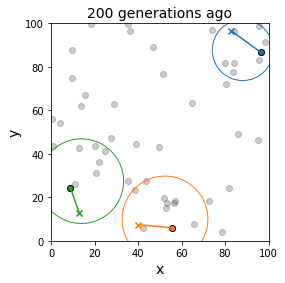

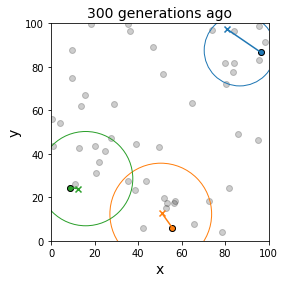

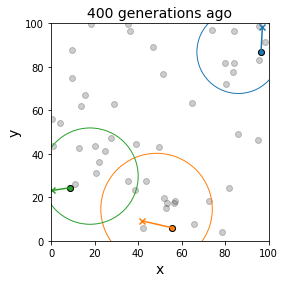

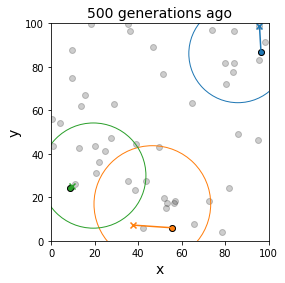

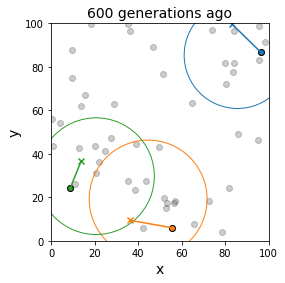

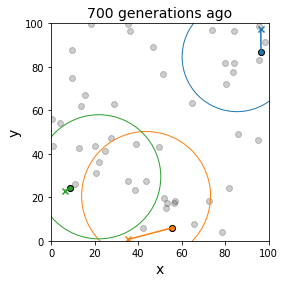

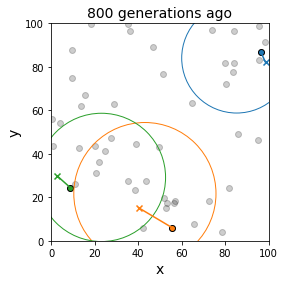

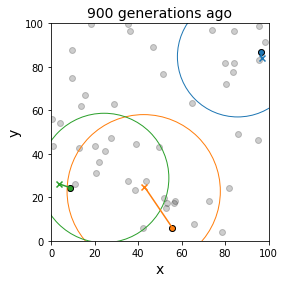

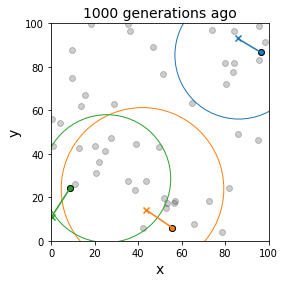

In [64]:
locus=0
samples=[0,2,4]
sample_colors = [ccolors(i) for i in range(len(samples))]

for i,t in enumerate(retain_gens):

    fig = plt.figure()
    ax = fig.add_subplot(111, aspect='equal')
    
    ax.scatter(real_anc_locs[0,:,0,0], real_anc_locs[0,:,0,1], color='k', alpha=0.1) #all samples
    
    for sample, sample_color in zip(samples, sample_colors):
        
        ax.scatter(real_anc_locs[locus,sample,0,0], real_anc_locs[locus,sample,0,1], color=sample_color, label=sample, edgecolors='k') #sample location
        ax.scatter(real_anc_locs[locus,sample,i,0], real_anc_locs[locus,sample,i,1], color=sample_color, marker='x') #ancestor location
        ax.plot([real_anc_locs[locus,sample,0,0],real_anc_locs[locus,sample,i,0]], [real_anc_locs[locus,sample,0,1],real_anc_locs[locus,sample,i,1]], color=sample_color) #connnect
        _plot_cov_ellipse(sigma*true_anc_vars[locus,sample,i,0], [true_anc_locs[locus,sample,i,0], true_anc_locs[locus,sample,i,1]], 
                          nstd=1.96, fill=False, color=sample_color) #95% CI
        
    ax.set_xlim(0,100)
    ax.set_ylim(0,100)
    ax.set_title('%d generations ago' %t, fontsize=14)
#     ax.legend()
    plt.xlabel('x', fontsize=14)
    plt.ylabel('y', fontsize=14)

    plt.savefig('plots/single-lineages-%dt.pdf' %t)
    
    plt.show()

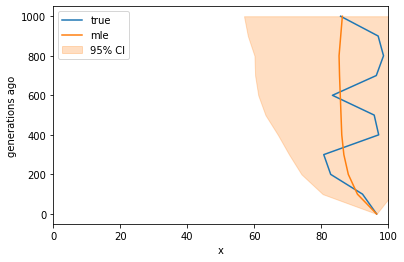

In [66]:
axis=0
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(real_anc_locs[0,0,:,axis], retain_gens, label='true')
ax.plot(true_anc_locs[0,0,:,axis], retain_gens, label='mle')
ax.fill_betweenx(retain_gens, 
                 true_anc_locs[0,0,:,axis] - 1.96*(sigma2*true_anc_vars[0,0,:,0])**0.5, true_anc_locs[0,0,:,axis] + 1.96*(sigma2*true_anc_vars[0,0,:,0])**0.5, 
                 color=ccolors(1), alpha=0.25 ,label='95% CI')
# ax.scatter(true_anc_locs[0,0,i,0], true_anc_locs[0,0,i,1], label='inferred')
# ax.scatter(real_anc_locs[0,0,i,0], real_anc_locs[0,0,i,1], label='true')
# _plot_cov_ellipse(sigma*true_anc_vars[0,0,i,0], [true_anc_locs[0,0,i,0], true_anc_locs[0,0,i,1]], nstd=1.96, fill=False, color=ccolors(0))
ax.set_xlim(0,100)
# ax.set_ylim(0,100)
# ax.set_title('%d generations ago' %t)
ax.legend()
if axis==0:
    ax.set_xlabel('x')
else:
    ax.set_xlabel('y')
ax.set_ylabel('generations ago')
plt.show()

In [68]:
prefix = 'data/sim_100000000L_1e-08RBP_2.0LAMBDA_1.0K_100W_1.0SIGMAcomp_%sSIGMAmate_%sSIGMAdisp_0selfing_40000MAXT' %(SIGMAmate,SIGMAdisp)

sse_mle = np.zeros(11)
sse_sample = np.zeros(11)
sse_mean_sample = np.zeros(11)
sse_mle_inf = np.zeros(11)
n = 0
n_inf = 0
nreps = range(10)
for rep in nreps:
    
    prefix_rep = prefix + '_%dnrep_10000Ne_1e-08U_100d_50k_2G' %rep
    
    # real ancestor locations at loci used for true trees
    filename = prefix_rep + '_100treeskip_anc-locs.npy'
    real_anc_locs = np.load(filename)

    # mle ancestor locations from true trees
    filename = prefix_rep + '_100treeskip_NonetCutoff_ancestor-locations.npy'
    true_anc_locs = np.load(filename)

    # sum squared error between mle and real ancestor locations
    sse_mle += np.sum(np.sum((real_anc_locs - true_anc_locs)**2, axis=-1), axis=(0,1))

    # sum squared error between sample locations and real ancestor locations
    sample_locs = np.repeat(real_anc_locs[:,:,0,:], 11, axis=-2).reshape(real_anc_locs.shape) #locations of samples
    sse_sample += np.sum(np.sum((real_anc_locs - sample_locs)**2, axis=-1), axis=(0,1))
    
    # sum squared error between mean sample location and real ancestor locations
    mean_loc = np.repeat(np.mean(real_anc_locs[:,:,0,:],axis=1), 11*100, axis=-2).reshape(real_anc_locs.shape) #mean sample location
    sse_mean_sample += np.sum(np.sum((real_anc_locs - mean_loc)**2, axis=-1), axis=(0,1))

    # for taking mean of sum squared errors
    n += len(real_anc_locs)*len(real_anc_locs[0]) #number of loci times number of samples

    # real ancestor locations at loci used for inferred trees
    filename = prefix_rep + '_100treeskip_anc-locs-inf.npy'
    real_anc_locs_inf = np.load(filename)    
    
    # mle ancestor locations from inferred trees
    for sample in range(100):
        try:
            filename = prefix_rep + '_5numiter_0.5threshold_100treeskip_1000M_NonetCutoff_ancestor-locations_%dsample.npy' %sample
            inf_anc_locs = np.load(filename)
            sse_mle_inf += np.sum(np.sum((real_anc_locs_inf[:,sample] - inf_anc_locs)**2, axis=-1), axis=0)
            n_inf += len(real_anc_locs_inf)
        except:
#             print('missing rep %d sample %d' %(rep,sample))
            pass

    
rmse_mle = (sse_mle/n)**0.5
rmse_sample = (sse_sample/n)**0.5
rmse_mean_sample = (sse_mean_sample/n)**0.5
rmse_mle_inf = (sse_mle_inf/n_inf)**0.5

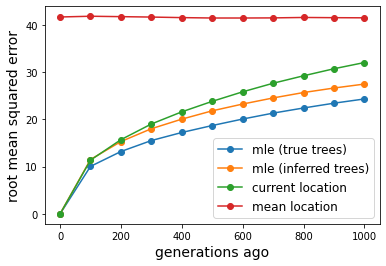

In [69]:
plt.plot(range(0,1001,100), rmse_mle, marker='o', label='mle (true trees)')
plt.plot(range(0,1001,100), rmse_mle_inf, marker='o', label='mle (inferred trees)')
plt.plot(range(0,1001,100), rmse_sample, marker='o', label='current location')
plt.plot(range(0,1001,100), rmse_mean_sample, marker='o', label='mean location')

plt.xlabel('generations ago', fontsize=14)
plt.ylabel('root mean squared error', fontsize=14)
plt.legend(fontsize=12)
# ratio = 1.0
# xleft, xright = plt.gca().get_xlim()
# ybottom, ytop = plt.gca().get_ylim()
# plt.gca().set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)

plt.savefig('plots/rmse-single-lineages.pdf')

plt.show()

## ancestor clouds

In [73]:
SIGMAmate = 0.5
SIGMAdisp = 0.75
prefix = 'data/sim_100000000L_1e-08RBP_2.0LAMBDA_1.0K_100W_1.0SIGMAcomp_%sSIGMAmate_%sSIGMAdisp_0selfing_40000MAXT_0nrep_10000Ne_1e-08U_100d_50k_2G_100treeskip' %(SIGMAmate, SIGMAdisp)
filename = prefix + '_anc-locs.npy'
real_anc_locs = np.load(filename)
filename = prefix + '_NonetCutoff_ancestor-locations.npy'
true_anc_locs = np.load(filename)
filename = prefix + '_NonetCutoff_ancestor-variances.npy'
true_anc_vars = np.load(filename)

In [74]:
retain_gens = range(0,1001,100)
sigma2 = SIGMAdisp**2 + SIGMAmate**2/2
sigma = np.array([[sigma2,0],[0,sigma2]])

/tmp/ipykernel_19382/1526635842.py:14: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(x=true_anc_locs[:,sample,i,0], y=true_anc_locs[:,sample,i,1], ax=ax, zorder=0, color=sample_color) #inferred
/tmp/ipykernel_19382/1526635842.py:16: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(x=real_anc_locs[:,sample,i,0], y=real_anc_locs[:,sample,i,1], ax=ax, zorder=0, alpha=0.1, color='k') #real


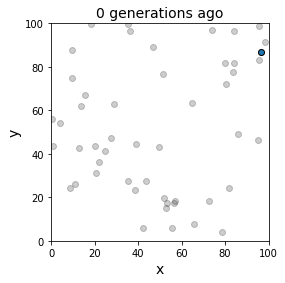

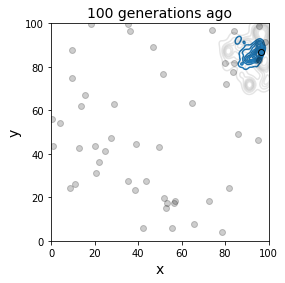

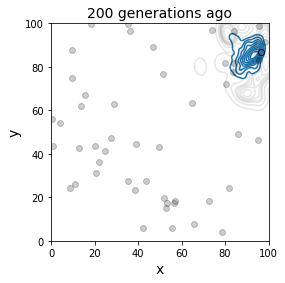

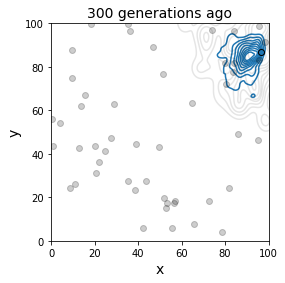

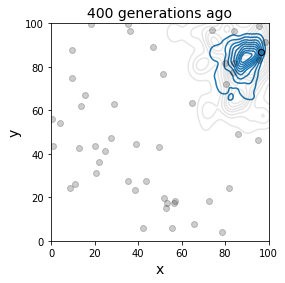

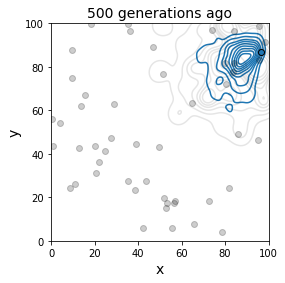

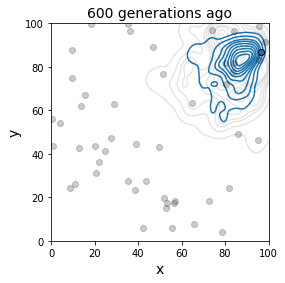

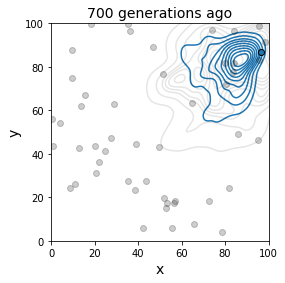

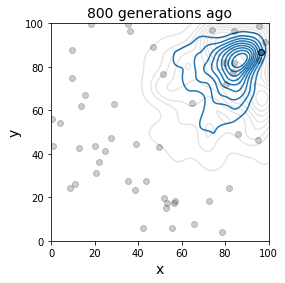

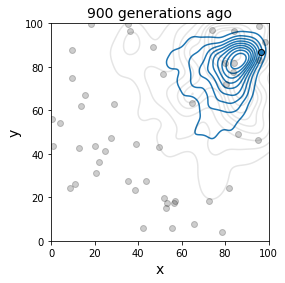

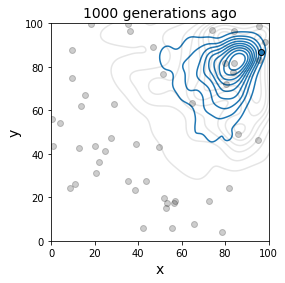

In [75]:
# sample=4
# sample_color = ccolors(2)
sample=0
sample_color = ccolors(0)

for i,t in enumerate(retain_gens):
    
    fig = plt.figure()
    ax = fig.add_subplot(111, aspect='equal')
    
    ax.scatter(real_anc_locs[0,:,0,0], real_anc_locs[0,:,0,1], color='k', alpha=0.1) #all samples
    ax.scatter(real_anc_locs[0,sample,0,0], real_anc_locs[0,sample,0,1], color=sample_color, zorder=1, edgecolors='k') #focal samples

    sns.kdeplot(x=true_anc_locs[:,sample,i,0], y=true_anc_locs[:,sample,i,1], ax=ax, zorder=0, color=sample_color) #inferred
#     ax.scatter(real_anc_locs[:,sample,i,0], real_anc_locs[:,sample,i,1], color=ccolors(1))
    sns.kdeplot(x=real_anc_locs[:,sample,i,0], y=real_anc_locs[:,sample,i,1], ax=ax, zorder=0, alpha=0.1, color='k') #real
    
    plt.xlim(0,100)
    plt.ylim(0,100)
    plt.title('%d generations ago' %t, fontsize=14)
    plt.xlabel('x', fontsize=14)
    plt.ylabel('y', fontsize=14)
    # plt.legend()
    
    plt.savefig('plots/ancestor-clouds-%dt.pdf' %t)
    
    plt.show()

In [24]:
prefix = 'data/sim_100000000L_1e-08RBP_2.0LAMBDA_1.0K_100W_1.0SIGMAcomp_%sSIGMAmate_%sSIGMAdisp_0selfing_40000MAXT' %(SIGMAmate,SIGMAdisp)

sse_mle = np.zeros(11)
sse_sample = np.zeros(11)
sse_mean_sample = np.zeros(11)
sse_mle_inf = np.zeros(11)
n = 0
n_inf=0
for rep in nreps:
    
    prefix_rep = prefix + '_%dnrep_10000Ne_1e-08U_100d_50k_2G' %rep
    
    filename = prefix_rep + '_100treeskip_anc-locs.npy'
    real_anc_locs = np.load(filename)
    
    filename = prefix_rep + '_100treeskip_NonetCutoff_ancestor-locations.npy'
    true_anc_locs = np.load(filename)

    sse_mle += np.sum(np.sum((np.mean(real_anc_locs, axis=0) - np.mean(true_anc_locs, axis=0))**2, axis=-1), axis=0)

    sample_locs = np.repeat(real_anc_locs[:,:,0,:], 11, axis=-2).reshape(real_anc_locs.shape) #locations of samples
    sse_sample += np.sum(np.sum((np.mean(real_anc_locs,axis=0) - np.mean(sample_locs,axis=0))**2, axis=-1), axis=0)
    
    mean_loc = np.repeat(np.mean(real_anc_locs[:,:,0,:],axis=1), 11*100, axis=-2).reshape(real_anc_locs.shape) #mean sample location
    sse_mean_sample += np.sum(np.sum((np.mean(real_anc_locs,axis=0) - np.mean(mean_loc,axis=0))**2, axis=-1), axis=0)

    n += len(real_anc_locs[0])
    
    # real ancestor locations at loci used for inferred trees
    filename = prefix_rep + '_100treeskip_anc-locs-inf.npy'
    real_anc_locs_inf = np.load(filename)    
    
    # mle ancestor locations from inferred trees
    for sample in range(100):
        try:
            filename = prefix_rep + '_5numiter_0.5threshold_100treeskip_1000M_NonetCutoff_ancestor-locations_%dsample.npy' %sample
            inf_anc_locs = np.load(filename)
            sse_mle_inf += np.sum((np.mean(real_anc_locs_inf[:,sample], axis=0) - np.mean(inf_anc_locs, axis=0))**2, axis=-1)
            n_inf += 1
        except:
#             print('missing rep %d sample %d' %(rep,sample))
            pass
    
rmse_mle = (sse_mle/n)**0.5
rmse_sample = (sse_sample/n)**0.5
rmse_mean_sample = (sse_mean_sample/n)**0.5
rmse_mle_inf = (sse_mle_inf/n_inf)**0.5

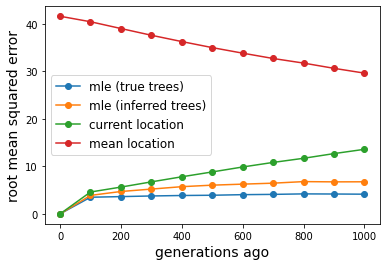

In [25]:
plt.plot(range(0,1001,100), rmse_mle, marker='o', label='mle (true trees)')
plt.plot(range(0,1001,100), rmse_mle_inf, marker='o', label='mle (inferred trees)')
plt.plot(range(0,1001,100), rmse_sample, marker='o', label='current location')
plt.plot(range(0,1001,100), rmse_mean_sample, marker='o', label='mean location')

plt.xlabel('generations ago', fontsize=14)
plt.ylabel('root mean squared error', fontsize=14)
plt.legend(fontsize=12)
# ratio = 1.0
# xleft, xright = plt.gca().get_xlim()
# ybottom, ytop = plt.gca().get_ylim()
# plt.gca().set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)

plt.savefig('plots/rmse-ancestor-clouds.pdf')

plt.show()

## blups

In [15]:
prefix = 'data/sim_100000000L_1e-08RBP_2.0LAMBDA_1.0K_100W_1.0SIGMAcomp_%sSIGMAmate_%sSIGMAdisp_0selfing_40000MAXT' %(SIGMAmate,SIGMAdisp)

sse_mle = np.zeros(11)
sse_sample = np.zeros(11)
sse_mean_sample = np.zeros(11)
sse_mle_inf = np.zeros(11)
n = 0
n_inf = 0
nreps = range(10)
for rep in nreps:
    
    prefix_rep = prefix + '_%dnrep_10000Ne_1e-08U_100d_50k_2G' %rep
    
    # real ancestor locations at loci used for true trees
    filename = prefix_rep + '_100treeskip_anc-locs.npy'
    real_anc_locs = np.load(filename)

    # mle ancestor locations from true trees
    filename = prefix_rep + '_100treeskip_NonetCutoff_ancestor-locations.npy'
    true_anc_locs = np.load(filename)

    # sum squared error between mle and real ancestor locations
    sse_mle += np.sum(np.sum((real_anc_locs - true_anc_locs)**2, axis=-1), axis=(0,1))

    # sum squared error between sample locations and real ancestor locations
    sample_locs = np.repeat(real_anc_locs[:,:,0,:], 11, axis=-2).reshape(real_anc_locs.shape) #locations of samples
    sse_sample += np.sum(np.sum((real_anc_locs - sample_locs)**2, axis=-1), axis=(0,1))
    
    # sum squared error between mean sample location and real ancestor locations
    mean_loc = np.repeat(np.mean(real_anc_locs[:,:,0,:],axis=1), 11*100, axis=-2).reshape(real_anc_locs.shape) #mean sample location
    sse_mean_sample += np.sum(np.sum((real_anc_locs - mean_loc)**2, axis=-1), axis=(0,1))

    # for taking mean of sum squared errors
    n += len(real_anc_locs)*len(real_anc_locs[0]) #number of loci times number of samples

    # real ancestor locations at loci used for inferred trees
    filename = prefix_rep + '_100treeskip_anc-locs-inf.npy'
    real_anc_locs_inf = np.load(filename)    
    
    # mle ancestor locations from inferred trees
    for sample in range(10):
        try:
            filename = prefix_rep + '_5numiter_0.5threshold_100treeskip_1000M_NonetCutoff_1000m_ancestor-locations_%dsample_blup.npy' %sample
            inf_anc_locs = np.squeeze(np.load(filename))
            sse_mle_inf += np.sum(np.sum((real_anc_locs_inf[:,sample] - inf_anc_locs)**2, axis=-1), axis=0)
            n_inf += len(real_anc_locs_inf)
        except:
#             print('missing rep %d sample %d' %(rep,sample))
            pass

    
rmse_mle = (sse_mle/n)**0.5
rmse_sample = (sse_sample/n)**0.5
rmse_mean_sample = (sse_mean_sample/n)**0.5
rmse_mle_inf = (sse_mle_inf/n_inf)**0.5

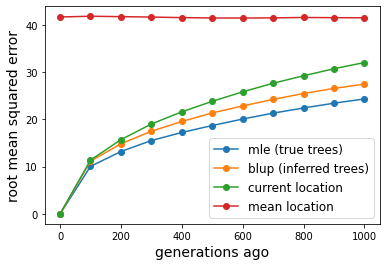

In [20]:
plt.plot(range(0,1001,100), rmse_mle, marker='o', label='mle (true trees)')
plt.plot(range(0,1001,100), rmse_mle_inf, marker='o', label='blup (inferred trees)')
plt.plot(range(0,1001,100), rmse_sample, marker='o', label='current location')
plt.plot(range(0,1001,100), rmse_mean_sample, marker='o', label='mean location')

plt.xlabel('generations ago', fontsize=14)
plt.ylabel('root mean squared error', fontsize=14)
plt.legend(fontsize=12)
# ratio = 1.0
# xleft, xright = plt.gca().get_xlim()
# ybottom, ytop = plt.gca().get_ylim()
# plt.gca().set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)

plt.savefig('plots/rmse-single-lineages-blup.pdf')

plt.show()

In [21]:
prefix = 'data/sim_100000000L_1e-08RBP_2.0LAMBDA_1.0K_100W_1.0SIGMAcomp_%sSIGMAmate_%sSIGMAdisp_0selfing_40000MAXT' %(SIGMAmate,SIGMAdisp)

sse_mle = np.zeros(11)
sse_sample = np.zeros(11)
sse_mean_sample = np.zeros(11)
sse_mle_inf = np.zeros(11)
n = 0
n_inf=0
for rep in nreps:
    
    prefix_rep = prefix + '_%dnrep_10000Ne_1e-08U_100d_50k_2G' %rep
    
    filename = prefix_rep + '_100treeskip_anc-locs.npy'
    real_anc_locs = np.load(filename)
    
    filename = prefix_rep + '_100treeskip_NonetCutoff_ancestor-locations.npy'
    true_anc_locs = np.load(filename)

    sse_mle += np.sum(np.sum((np.mean(real_anc_locs, axis=0) - np.mean(true_anc_locs, axis=0))**2, axis=-1), axis=0)

    sample_locs = np.repeat(real_anc_locs[:,:,0,:], 11, axis=-2).reshape(real_anc_locs.shape) #locations of samples
    sse_sample += np.sum(np.sum((np.mean(real_anc_locs,axis=0) - np.mean(sample_locs,axis=0))**2, axis=-1), axis=0)
    
    mean_loc = np.repeat(np.mean(real_anc_locs[:,:,0,:],axis=1), 11*100, axis=-2).reshape(real_anc_locs.shape) #mean sample location
    sse_mean_sample += np.sum(np.sum((np.mean(real_anc_locs,axis=0) - np.mean(mean_loc,axis=0))**2, axis=-1), axis=0)

    n += len(real_anc_locs[0])
    
    # real ancestor locations at loci used for inferred trees
    filename = prefix_rep + '_100treeskip_anc-locs-inf.npy'
    real_anc_locs_inf = np.load(filename)    
    
    # mle ancestor locations from inferred trees
    for sample in range(10):
        try:
            filename = prefix_rep + '_5numiter_0.5threshold_100treeskip_1000M_NonetCutoff_1000m_ancestor-locations_%dsample_blup.npy' %sample
            inf_anc_locs = np.squeeze(np.load(filename))
            sse_mle_inf += np.sum((np.mean(real_anc_locs_inf[:,sample], axis=0) - np.mean(inf_anc_locs, axis=0))**2, axis=-1)
            n_inf += 1
        except:
#             print('missing rep %d sample %d' %(rep,sample))
            pass
    
rmse_mle = (sse_mle/n)**0.5
rmse_sample = (sse_sample/n)**0.5
rmse_mean_sample = (sse_mean_sample/n)**0.5
rmse_mle_inf = (sse_mle_inf/n_inf)**0.5

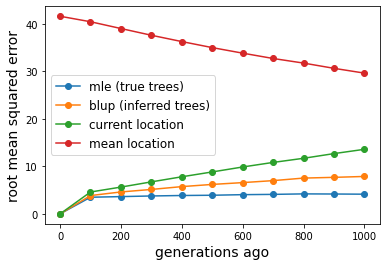

In [23]:
plt.plot(range(0,1001,100), rmse_mle, marker='o', label='mle (true trees)')
plt.plot(range(0,1001,100), rmse_mle_inf, marker='o', label='blup (inferred trees)')
plt.plot(range(0,1001,100), rmse_sample, marker='o', label='current location')
plt.plot(range(0,1001,100), rmse_mean_sample, marker='o', label='mean location')

plt.xlabel('generations ago', fontsize=14)
plt.ylabel('root mean squared error', fontsize=14)
plt.legend(fontsize=12)
# ratio = 1.0
# xleft, xright = plt.gca().get_xlim()
# ybottom, ytop = plt.gca().get_ylim()
# plt.gca().set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)

plt.savefig('plots/rmse-ancestor-clouds-blup.pdf')

plt.show()